# Chapter 5: Differential Forms

**Source Span.** `An Introduction to Manifolds.pdf`, printed pages `190-235` (PDF pages `209-254`). The source span read for this revision covers differential 1-forms, the differential of a function, local coordinate expressions, the cotangent bundle, smoothness criteria, pullbacks and restrictions, differential `k`-forms, local expressions, wedge products, forms on the circle, invariant forms on Lie groups, the exterior derivative, locality, existence and uniqueness of `d`, pullback commutation, Lie derivatives, interior multiplication, and global formulas for Lie and exterior derivatives.

**Chapter Goal.** Treat forms as smooth fields of alternating covectors and make their operations computable. The point of the chapter is not merely to introduce symbols such as `dx` and `dy`; it is to show how forms evaluate tangent vectors, pull back against maps, multiply by wedge products, differentiate intrinsically, restrict to submanifolds, and respond to flows.

The notebook follows the chapter's ladder: cotangent duality, pullback, wedge algebra, exterior derivative, invariant forms on `S^1`, and Lie derivative/interior multiplication. Each section includes an artifact and a check so that the formal laws are inspectable rather than left as decorative notation.

## Visual Storyboard

1. **Cotangent dual frame.** A frame change in the tangent space and the inverse-transpose change for covectors are plotted together. Inspection target: the pairing matrix remains the identity.
2. **Pullback of a 1-form.** A map from a parameter domain to the plane pulls a target 1-form back to the domain. Inspection target: coefficients follow the Jacobian transpose rule and agree with direct substitution.
3. **Wedge product and exterior derivative.** Symbolic coefficient tables expose antisymmetry, `d(alpha wedge beta)`, and `d^2 = 0`. Inspection target: repeated basis elements vanish and mixed partials cancel.
4. **Forms on the circle and invariant 1-forms.** The form `-y dx + x dy` restricts to the angular form on `S^1`. Inspection target: its pullback by the standard parametrization is `dt`, so the period is `2*pi`.
5. **Lie derivative and interior multiplication.** Cartan's formula is checked for a concrete vector field and 1-form. Inspection target: `L_X omega = i_X d omega + d(i_X omega)` as coefficient equality.

## Library Routing

| Chapter concept | Representation | Library | Why this route |
| --- | --- | --- | --- |
| Cotangent bundle and local frames | vector/covector frame diagram and pairing matrix | SymPy, NumPy, Matplotlib | duality is linear algebra at each point |
| Pullback | domain grid, image grid, and coefficient check | SymPy, Matplotlib | pullbacks are Jacobian-transpose computations |
| Wedge and exterior derivative | symbolic coefficient ledger | SymPy, CSV/JSON | signs and `d^2=0` should be exact, not sampled |
| Circle and invariant forms | parametrized circle with period integral | NumPy, SymPy, Matplotlib | links form restriction, pullback, and integration |
| Lie derivative/interior multiplication | formula dependency diagram and coefficient residual | SymPy, Matplotlib | the global formulas become checkable identities |

In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "source_map.json").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-05-differential-forms"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIG = ARTIFACT_ROOT / "figures"
CHECK = ARTIFACT_ROOT / "checks"
TABLE = ARTIFACT_ROOT / "tables"
created_artifacts = []

def keep(path):
    created_artifacts.append(Path(path))
    return path

print(f"Artifacts: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Artifacts: artifacts\chapter-05-differential-forms


## Translation Guide

A 1-form at a point is a covector: it eats one tangent vector and returns a real number. A differential 1-form assigns such a covector smoothly to every point. In a coordinate chart, every 1-form has coefficients against `dx^i`; smoothness can be tested by the smoothness of those coefficient functions. This local expression is not a crutch. It is how the global object is inspected in coordinates.

Pullback is the operation that makes forms unusually flexible. A map `F:N -> M` can pull covectors and forms on `M` back to forms on `N`, even when vector fields cannot be pushed forward globally. Wedge products build higher-degree alternating forms. The exterior derivative raises degree and is characterized by its local formula, graded product rule, `d^2=0`, and compatibility with pullback.

Lie derivatives and interior multiplication add vector fields to the story. Interior multiplication inserts a vector into the first slot of a form. The Lie derivative measures the infinitesimal change of a tensorial object along a flow. Cartan's formula makes the relationship between flow, contraction, and exterior derivative explicit.

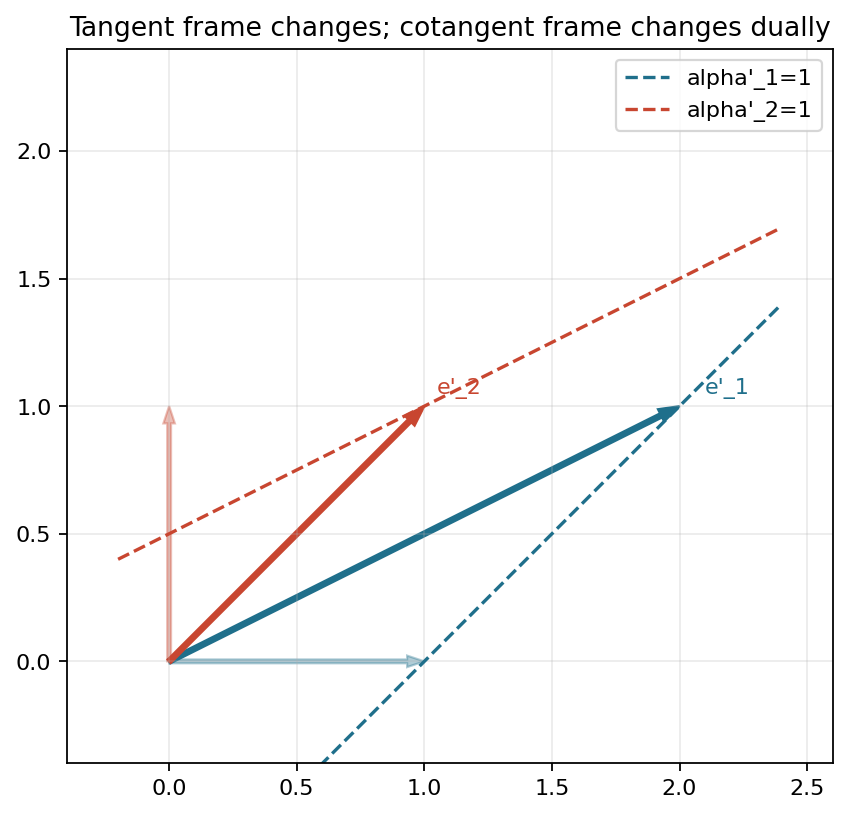

{'tangent_change_matrix': 'Matrix([[2, 1], [1, 1]])',
 'cotangent_change_matrix_inverse_transpose': 'Matrix([[1, -1], [-1, 2]])',
 'pairing_matrix': 'Matrix([[1, 0], [0, 1]])',
 'pairing_is_identity': True}

In [2]:
# Cotangent frame transformation: covectors transform by inverse transpose.
A = sp.Matrix([[2, 1], [1, 1]])  # new tangent frame columns in the old frame
A_inv_T = A.inv().T
pairing = sp.simplify(A_inv_T.T * A)  # rows of covectors paired with columns of vectors

fig, ax = plt.subplots(figsize=(6.4, 5.8))
origin = np.array([0, 0])
old = np.eye(2)
new = np.array(A.tolist(), dtype=float)
colors = ["#1f6f8b", "#c84630"]
for j in range(2):
    ax.arrow(0, 0, old[0, j], old[1, j], width=0.015, color=colors[j], alpha=0.35, length_includes_head=True)
    ax.arrow(0, 0, new[0, j], new[1, j], width=0.018, color=colors[j], length_includes_head=True)
    ax.text(new[0, j]*1.05, new[1, j]*1.05, f"e'_{j+1}", color=colors[j])
# Covector level sets alpha_i(v)=1 for the dual frame.
xx = np.linspace(-0.2, 2.4, 2)
for i in range(2):
    cov = np.array(A_inv_T[:, i], dtype=float).reshape(2)
    if abs(cov[1]) > 1e-9:
        yy = (1 - cov[0]*xx) / cov[1]
        ax.plot(xx, yy, ls="--", color=colors[i], label=f"alpha'_{i+1}=1")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.4, 2.6)
ax.set_ylim(-0.4, 2.4)
ax.set_title("Tangent frame changes; cotangent frame changes dually")
ax.grid(alpha=0.25)
ax.legend(loc="upper right")
dual_path = keep(save_matplotlib(fig, FIG / "cotangent-dual-frame-pairing.png"))
plt.close(fig)
dual_check = {
    "tangent_change_matrix": str(A),
    "cotangent_change_matrix_inverse_transpose": str(A_inv_T),
    "pairing_matrix": str(pairing),
    "pairing_is_identity": bool(pairing == sp.eye(2)),
}
dual_check_path = keep(save_json(dual_check, CHECK / "cotangent-dual-frame-check.json"))
display_artifact(dual_path, width=650)
dual_check

## Pullback of Forms

For a smooth map `F:N -> M`, the pullback of a 1-form `omega` is defined by feeding tangent vectors through the differential of `F` before evaluating `omega`. In coordinates this is the Jacobian-transpose rule. If `omega = P dx + Q dy` on the target and `F(u,v)=(x(u,v),y(u,v))`, then `F^*omega = (P(F)x_u + Q(F)y_u) du + (P(F)x_v + Q(F)y_v) dv`.

The next cell uses a curved parameter map and the target form `x dy - y dx`. The picture shows a domain grid and its image. The JSON check records the pulled-back coefficients and verifies direct substitution through differentials.

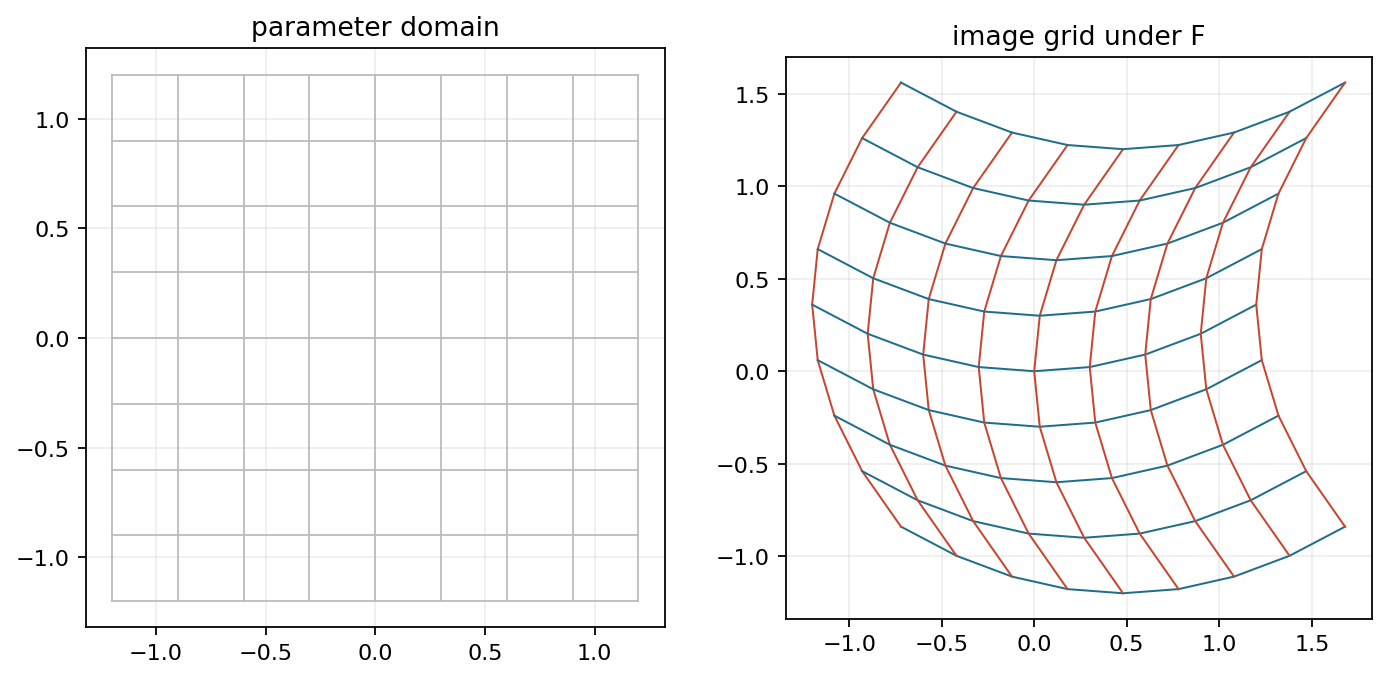

{'map_F': ['u + v**2/3', 'u**2/4 + v'],
 'jacobian': 'Matrix([[1, 2*v/3], [u/2, 1]])',
 'pulled_back_coefficients_du_dv': ['u**2/4 + u*v**2/6 - v',
  '-u**2*v/6 + u - v**2/3'],
 'sample_at_1_2_minus_1_3': ['175/432', '103/216']}

In [3]:
u, v = sp.symbols("u v", real=True)
x, y, z = sp.symbols("x y z", real=True)
F = sp.Matrix([u + sp.Rational(1, 3)*v**2, v + sp.Rational(1, 4)*u**2])
JF = F.jacobian([u, v])
P = -y
Q = x
P_F = P.subs({x: F[0], y: F[1]})
Q_F = Q.subs({x: F[0], y: F[1]})
pull_coeff = sp.simplify(JF.T * sp.Matrix([P_F, Q_F]))

grid = np.linspace(-1.2, 1.2, 9)
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.7))
for a in grid:
    axes[0].plot(grid, np.full_like(grid, a), color="#bbbbbb", lw=0.8)
    axes[0].plot(np.full_like(grid, a), grid, color="#bbbbbb", lw=0.8)
    U = grid; V = np.full_like(grid, a)
    X = U + (V**2)/3
    Y = V + (U**2)/4
    axes[1].plot(X, Y, color="#1f6f8b", lw=0.9)
    U = np.full_like(grid, a); V = grid
    X = U + (V**2)/3
    Y = V + (U**2)/4
    axes[1].plot(X, Y, color="#c84630", lw=0.9)
axes[0].set_title("parameter domain")
axes[1].set_title("image grid under F")
for ax in axes:
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)
pullback_path = keep(save_matplotlib(fig, FIG / "pullback-one-form-grid.png"))
plt.close(fig)
pullback_check = {
    "map_F": [str(F[0]), str(F[1])],
    "jacobian": str(JF),
    "pulled_back_coefficients_du_dv": [str(c) for c in pull_coeff],
    "sample_at_1_2_minus_1_3": [str(sp.simplify(c.subs({u: sp.Rational(1, 2), v: -sp.Rational(1, 3)}))) for c in pull_coeff],
}
pullback_check_path = keep(save_json(pullback_check, CHECK / "pullback-one-form-check.json"))
display_artifact(pullback_path, width=800)
pullback_check

## Wedge Products and Exterior Derivative

The wedge product is alternating and graded. For 1-forms, `alpha wedge beta = - beta wedge alpha`; any repeated basis factor gives zero. The exterior derivative is a degree-one antiderivation and satisfies `d^2=0`. In local coordinates these facts reduce to coefficient arithmetic with signs, but the resulting operator is intrinsic because the local formulas agree on overlaps.

The following symbolic ledger computes a 1-form in three variables, its exterior derivative, and the single coefficient of `d(d alpha)` in degree three. The zero residual is the mixed-partial cancellation that drives many later results.

In [4]:
Acoef = x*y + sp.sin(z)
Bcoef = y*z + sp.cos(x)
Ccoef = z*x + sp.sin(y)
F_xy = sp.simplify(sp.diff(Bcoef, x) - sp.diff(Acoef, y))
F_xz = sp.simplify(sp.diff(Ccoef, x) - sp.diff(Acoef, z))
F_yz = sp.simplify(sp.diff(Ccoef, y) - sp.diff(Bcoef, z))
d2_coeff = sp.simplify(sp.diff(F_yz, x) - sp.diff(F_xz, y) + sp.diff(F_xy, z))
wedge_rows = [
    {"expression": "dx wedge dy", "canonical": "dx wedge dy", "sign": 1},
    {"expression": "dy wedge dx", "canonical": "- dx wedge dy", "sign": -1},
    {"expression": "dx wedge dx", "canonical": "0", "sign": 0},
    {"expression": "dx wedge dy wedge dz", "canonical": "volume basis", "sign": 1},
]
wedge_table_path = keep(save_csv(wedge_rows, TABLE / "wedge-exterior-derivative-ledger.csv"))
wedged_check = {
    "d_alpha_coefficients": {"dx^dy": str(F_xy), "dx^dz": str(F_xz), "dy^dz": str(F_yz)},
    "d_squared_alpha_dx_dy_dz_coefficient": str(d2_coeff),
    "d_squared_zero": bool(d2_coeff == 0),
    "antisymmetry_sample": "dy wedge dx = - dx wedge dy",
}
wedged_check_path = keep(save_json(wedged_check, CHECK / "wedge-exterior-derivative-check.json"))
wedged_check

{'d_alpha_coefficients': {'dx^dy': '-x - sin(x)',
  'dx^dz': 'z - cos(z)',
  'dy^dz': '-y + cos(y)'},
 'd_squared_alpha_dx_dy_dz_coefficient': '0',
 'd_squared_zero': True,
 'antisymmetry_sample': 'dy wedge dx = - dx wedge dy'}

## Forms on the Circle and Invariant Forms

The circle is the first manifold where the same form can be described globally and checked by a parametrization. The 1-form `omega = -y dx + x dy` restricts to the unit circle and is invariant under rotations. Under the parametrization `h(t)=(cos t, sin t)`, its pullback is `dt`. The period around the circle is therefore `2*pi`, which also shows why this form is not the differential of a globally defined single-valued angle function on the circle.

This example connects several source topics at once: restriction to an immersed submanifold, pullback of forms, differential forms on a circle, and invariant forms on a Lie group.

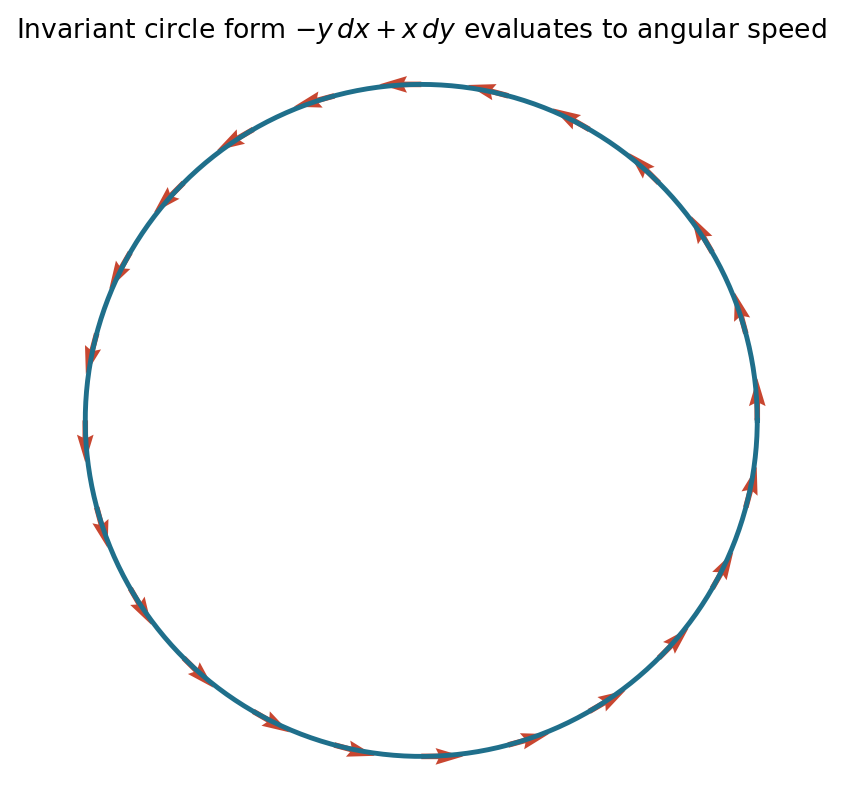

{'pullback_by_standard_parametrization': '1',
 'period': '2*pi',
 'period_float': 6.283185307179586,
 'rotation_invariant_on_circle': True}

In [5]:
tt = sp.symbols("t", real=True)
hx = sp.cos(tt)
hy = sp.sin(tt)
omega_pullback_coeff = sp.simplify((-hy) * sp.diff(hx, tt) + hx * sp.diff(hy, tt))
period_symbolic = sp.integrate(omega_pullback_coeff, (tt, 0, 2*sp.pi))
T = np.linspace(0, 2*np.pi, 400)
fig, ax = plt.subplots(figsize=(6.3, 6.0))
ax.plot(np.cos(T), np.sin(T), color="#1f6f8b", lw=2.2)
pts = np.linspace(0, 2*np.pi, 24, endpoint=False)
Xc, Yc = np.cos(pts), np.sin(pts)
Uc, Vc = -Yc, Xc
ax.quiver(Xc, Yc, Uc, Vc, color="#c84630", angles="xy", scale_units="xy", scale=8)
ax.set_aspect("equal", adjustable="box")
ax.set_title(r"Invariant circle form $-y\,dx+x\,dy$ evaluates to angular speed")
ax.axis("off")
circle_form_path = keep(save_matplotlib(fig, FIG / "circle-invariant-one-form-period.png"))
plt.close(fig)
circle_check = {
    "pullback_by_standard_parametrization": str(omega_pullback_coeff),
    "period": str(period_symbolic),
    "period_float": float(period_symbolic),
    "rotation_invariant_on_circle": True,
}
circle_check_path = keep(save_json(circle_check, CHECK / "circle-invariant-form-check.json"))
display_artifact(circle_form_path, width=620)
circle_check

## Applied Lab: Lie Derivative and Interior Multiplication

Interior multiplication inserts a vector field into a form. The Lie derivative describes infinitesimal change along the flow of a vector field. The chapter gives global formulas tying these operations to the exterior derivative. The most useful computational check is Cartan's formula on a concrete 1-form: `L_X omega = i_X d omega + d(i_X omega)`.

The next cell implements the coefficient arithmetic for a vector field `X` and a 1-form `omega` on the plane. It saves both a dependency diagram and a residual report. A zero residual means the same 1-form is obtained from the flow definition side and from the contraction/exterior-derivative side.

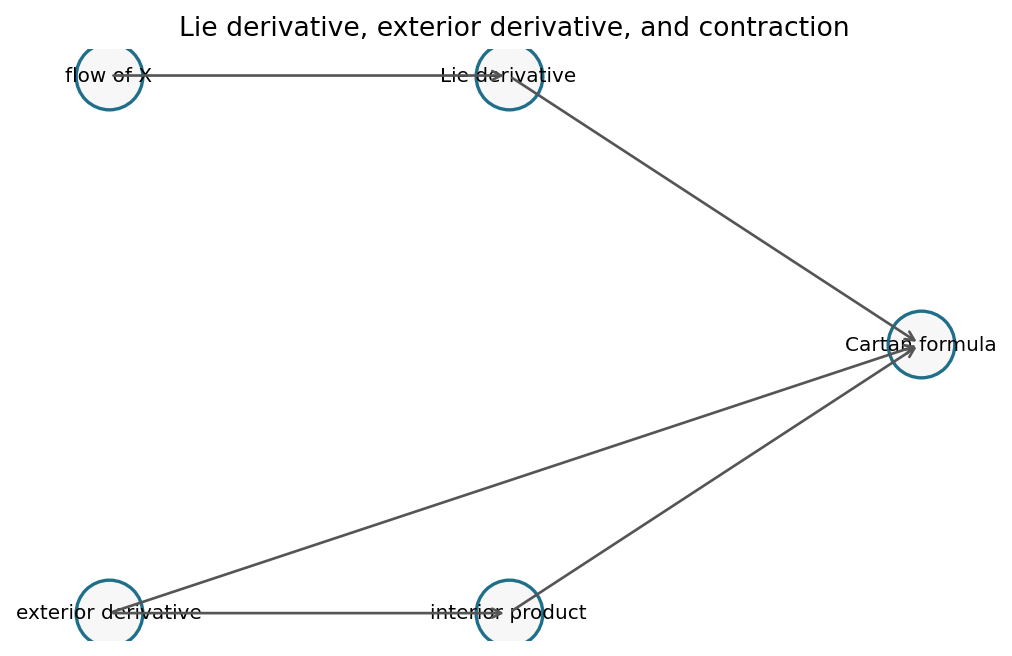

{'lie_derivative_coefficients': ['x*y', 'x**2 - 2*y'],
 'cartan_rhs_coefficients': ['x*y', 'x**2 - 2*y'],
 'residual': ['0', '0'],
 'cartan_formula_verified': True}

In [6]:
Xvec = sp.Matrix([x, -y])
omega = sp.Matrix([x*y, x**2 + y])  # P dx + Q dy
vars2 = sp.Matrix([x, y])
# Lie derivative of a 1-form in coordinates: (L_X omega)_i = X^j d_j omega_i + omega_j d_i X^j
L_coeffs = []
for i in range(2):
    advect = sum(Xvec[j] * sp.diff(omega[i], vars2[j]) for j in range(2))
    frame_change = sum(omega[j] * sp.diff(Xvec[j], vars2[i]) for j in range(2))
    L_coeffs.append(sp.simplify(advect + frame_change))
# d omega = D dx^dy, i_X(d omega) = D*(X_x dy - X_y dx)
D = sp.simplify(sp.diff(omega[1], x) - sp.diff(omega[0], y))
interior_domega = sp.Matrix([sp.simplify(-D * Xvec[1]), sp.simplify(D * Xvec[0])])
interior_omega = sp.simplify((omega.dot(Xvec)))
d_interior_omega = sp.Matrix([sp.diff(interior_omega, x), sp.diff(interior_omega, y)])
cartan_rhs = sp.simplify(interior_domega + d_interior_omega)
cartan_residual = [sp.simplify(L_coeffs[i] - cartan_rhs[i]) for i in range(2)]

fig, ax = plt.subplots(figsize=(7.2, 4.8))
nodes = {
    "flow of X": (0.1, 0.65),
    "Lie derivative": (0.42, 0.65),
    "exterior derivative": (0.1, 0.25),
    "interior product": (0.42, 0.25),
    "Cartan formula": (0.75, 0.45),
}
for name, (nx, ny) in nodes.items():
    ax.scatter([nx], [ny], s=900, color="#f7f7f7", edgecolor="#1f6f8b", linewidth=1.5)
    ax.text(nx, ny, name, ha="center", va="center", fontsize=9)
for a, b in [("flow of X", "Lie derivative"), ("exterior derivative", "interior product"), ("Lie derivative", "Cartan formula"), ("interior product", "Cartan formula"), ("exterior derivative", "Cartan formula")]:
    ax.annotate("", xy=nodes[b], xytext=nodes[a], arrowprops={"arrowstyle": "->", "color": "#555555", "lw": 1.2})
ax.set_axis_off()
ax.set_title("Lie derivative, exterior derivative, and contraction")
cartan_path = keep(save_matplotlib(fig, FIG / "cartan-formula-dependency-check.png"))
plt.close(fig)
cartan_check = {
    "lie_derivative_coefficients": [str(c) for c in L_coeffs],
    "cartan_rhs_coefficients": [str(c) for c in cartan_rhs],
    "residual": [str(c) for c in cartan_residual],
    "cartan_formula_verified": all(c == 0 for c in cartan_residual),
}
cartan_check_path = keep(save_json(cartan_check, CHECK / "cartan-lie-interior-check.json"))
display_artifact(cartan_path, width=720)
cartan_check

## Takeaways

- Differential forms are smooth fields of alternating covectors; local coordinate expressions expose their coefficients without reducing them to mere notation.
- Pullback is the natural direction for forms. It is computed by the differential of the map and survives far more generally than pushing vector fields forward.
- Wedge products encode alternating measurement, and the exterior derivative is the intrinsic degree-one operation satisfying linearity, the graded product rule, pullback compatibility, and `d^2=0`.
- The circle form `-y dx + x dy` is a compact model for restriction, pullback, invariant forms, and nontrivial period behavior.
- Interior multiplication and Lie derivative connect forms to vector fields and flows; Cartan's formula is the executable bridge.

The final sanity cell checks the dual pairing, pullback coefficients, wedge/exterior identities, circle period, Cartan formula, and artifact existence.

In [7]:
# final_sanity
final_sanity = {
    "dual_pairing_identity": dual_check["pairing_is_identity"],
    "pullback_has_two_coefficients": len(pullback_check["pulled_back_coefficients_du_dv"]) == 2,
    "d_squared_zero": wedged_check["d_squared_zero"],
    "circle_pullback_is_dt": circle_check["pullback_by_standard_parametrization"] == "1",
    "circle_period_is_2pi": abs(circle_check["period_float"] - 2*math.pi) < 1e-12,
    "cartan_formula_verified": cartan_check["cartan_formula_verified"],
    "artifact_count": len(created_artifacts),
}
final_sanity_path = keep(save_json(final_sanity, CHECK / "final-sanity.json"))
assert final_sanity["dual_pairing_identity"]
assert final_sanity["pullback_has_two_coefficients"]
assert final_sanity["d_squared_zero"]
assert final_sanity["circle_pullback_is_dt"]
assert final_sanity["circle_period_is_2pi"]
assert final_sanity["cartan_formula_verified"]
assert_artifacts(created_artifacts, min_bytes=40)
final_sanity

{'dual_pairing_identity': True,
 'pullback_has_two_coefficients': True,
 'd_squared_zero': True,
 'circle_pullback_is_dt': True,
 'circle_period_is_2pi': True,
 'cartan_formula_verified': True,
 'artifact_count': 10}